In [ ]:
!pip install yfinance --upgrade --no-cache-dir
# it's a standard library for optimization
!pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.1/127.1 kB 56.8 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 23.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Making charts look nice
plt.style.use('fivethirtyeight')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import requests
import pandas as pd
import io

def get_nifty_100_live():
    # URL for the official Nifty 100 stock list CSV
    url = "https://niftyindices.com/IndexConstituent/ind_nifty100list.csv"

    # We need to fake a browser visit, otherwise they block the request
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    try:
        # 1. Fetch the content
        response = requests.get(url, headers=headers)
        response.raise_for_status() # Check if request was successful

        # 2. Read the content into a Pandas DataFrame
        df = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

        # 3. Clean up the data
        # Yahoo Finance needs tickers to have '.NS' at the end (e.g., RELIANCE.NS)
        df['Yahoo_Ticker'] = df['Symbol'] + ".NS"

        # 4. Create a Sector Map (We need this for the constraints later!)
        # The CSV usually has a column 'Industry' or 'Sector'
        sector_map = pd.Series(df['Industry'].values, index=df['Yahoo_Ticker']).to_dict()

        return df['Yahoo_Ticker'].tolist(), sector_map, df

    except Exception as e:
        print(f"Error scraping data: {e}")
        return [], {}, None

# Execute the function
tickers, sector_map, full_df = get_nifty_100_live()

# Display the results
print(f"Successfully scraped {len(tickers)} stocks.")
print("\nSample Tickers:", tickers[:5])
print("\nSample Sector Map:", list(sector_map.items())[:5])

# Show the first few rows of the dataframe to verify we have Sectors
full_df.head()

Successfully scraped 101 stocks.

Sample Tickers: ['ABB.NS', 'ADANIENSOL.NS', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS']

Sample Sector Map: [('ABB.NS', 'Capital Goods'), ('ADANIENSOL.NS', 'Power'), ('ADANIENT.NS', 'Metals & Mining'), ('ADANIGREEN.NS', 'Power'), ('ADANIPORTS.NS', 'Services')]


,Company Name,Industry,Symbol,Series,ISIN Code,Yahoo_Ticker
0,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022,ABB.NS
1,Adani Energy Solutions Ltd.,Power,ADANIENSOL,EQ,INE931S01010,ADANIENSOL.NS
2,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024,ADANIENT.NS
3,Adani Green Energy Ltd.,Power,ADANIGREEN,EQ,INE364U01010,ADANIGREEN.NS
4,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042,ADANIPORTS.NS


In [ ]:
# --- FIXING THE DATA LOSS (CORRECTED) ---
import yfinance as yf
from datetime import datetime
import pandas as pd

# 1. Download the raw data
# We re-download to ensure everything is fresh and variables exist
print("Downloading Nifty 100 Data...")
data_raw = yf.download(tickers, start='2020-01-01', end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)

# 2. Extract 'Close' prices
# yfinance might return a MultiIndex if multiple tickers are downloaded. We handle that.
if isinstance(data_raw.columns, pd.MultiIndex):
    df_close = data_raw['Close']
else:
    df_close = data_raw

# 3. Identify and Drop "Young" Stocks (>10% missing data)
missing_fractions = df_close.isnull().mean()
print("\nStocks with >10% missing data will be dropped:")
print(missing_fractions[missing_fractions > 0.1].index.tolist())

valid_stocks = missing_fractions[missing_fractions < 0.1].index
data_cleaned = df_close[valid_stocks]

# 4. FIX: Download Benchmark Data (This was missing!)
print("\nDownloading Benchmark (Nifty 50)...")
benchmark_raw = yf.download("^NSEI", start='2020-01-01', end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)
benchmark_data = benchmark_raw['Close'] # Extract Close column

# 5. Clean and Align Data
data = data_cleaned.ffill().dropna()
benchmark_data = benchmark_data.ffill().dropna()

# Align the dates (Intersecion of indices)
common_dates = data.index.intersection(benchmark_data.index)
data = data.loc[common_dates]
benchmark_data = benchmark_data.loc[common_dates]

# 6. Filter the sector map
final_tickers = data.columns.tolist()
# Check if sector_map exists (from previous scraping), if not, fill with Unknown
if 'sector_map' not in locals():
    print("Warning: 'sector_map' not found. Sectors set to Unknown.")
    cleaned_sector_map = {t: "Unknown" for t in final_tickers}
else:
    cleaned_sector_map = {ticker: sector_map.get(ticker, "Unknown") for ticker in final_tickers}

print("\n------------------------------------------------")
print("FIX COMPLETE")
print(f"Stocks Kept: {len(final_tickers)}")
print(f"Final Data Shape: {data.shape}")
print("------------------------------------------------")

[***                    6%                       ]  6 of 101 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DUMMYHDLVR.NS"}}}
ERROR:yfinance:$DUMMYHDLVR.NS: possibly delisted; no timezone found
[*********************100%***********************]  101 of 101 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DUMMYHDLVR.NS']: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed


Stocks with >10% missing data will be dropped:
['ADANIENSOL.NS', 'BAJAJHFL.NS', 'DUMMYHDLVR.NS', 'ENRIN.NS', 'ETERNAL.NS', 'HYUNDAI.NS', 'IRFC.NS', 'JIOFIN.NS', 'LICI.NS', 'LODHA.NS', 'MAXHEALTH.NS', 'MAZDOCK.NS', 'TMPV.NS', 'UNITDSPR.NS']


------------------------------------------------
FIX COMPLETE
Stocks Kept: 87
Final Data Shape: (1480, 87)
------------------------------------------------


In [ ]:
# Step 2.1: Convert Prices to Returns
# pct_change() calculates the % change from the previous day
returns = data.pct_change().dropna()
benchmark_returns = benchmark_data.pct_change().dropna()

print("Returns calculated.")
print(f"Returns Data Shape: {returns.shape}")

# Let's verify the data looks correct by peeking at the first few rows
returns.tail(10)

Returns calculated.
Returns Data Shape: (1479, 87)


Ticker,ABB.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,...,TECHM.NS,TITAN.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-09,0.011765,0.013085,0.005132,0.011280,0.019850,0.007751,-0.000705,-0.045180,0.001649,-0.007201,...,-0.018972,0.021768,0.001037,-0.001247,0.000498,-0.010919,0.003725,0.009584,-0.015189,-0.004705
2025-12-10,0.006840,-0.014965,-0.009110,0.000601,-0.004372,-0.006285,-0.010224,0.003040,0.002116,0.003348,...,-0.006916,-0.000857,0.008103,-0.016424,-0.002186,-0.008498,0.002969,0.015596,0.002214,0.003640
2025-12-11,0.017566,0.029888,0.029299,0.003938,-0.004250,0.012082,-0.001282,-0.008950,-0.004614,0.006951,...,0.011220,-0.000234,0.001212,0.007267,0.008540,0.013696,0.011735,0.009252,0.004923,-0.001137
2025-12-12,0.006772,0.002063,0.021005,0.012500,0.027813,0.022477,0.013054,-0.005253,0.010529,-0.004252,...,0.006504,0.009207,-0.001974,0.006893,0.004894,0.021879,0.003030,0.027502,0.005207,0.007154
2025-12-15,0.001326,-0.001533,0.007114,-0.006698,-0.000761,0.009669,-0.002042,0.005570,-0.001011,-0.008319,...,-0.001901,-0.003608,-0.002347,0.008245,-0.004350,0.000427,-0.004896,0.010670,0.004374,-0.008126
2025-12-16,-0.008136,-0.013603,-0.018519,-0.008991,0.006580,-0.008583,-0.004939,0.003849,-0.050747,0.007606,...,0.001777,0.016373,-0.004626,-0.000073,-0.005413,-0.017053,-0.000942,0.036585,-0.009628,-0.007867
2025-12-17,-0.013544,-0.006851,-0.007294,-0.008472,-0.016032,-0.013486,-0.018436,-0.001863,0.004182,-0.012544,...,0.000760,-0.005497,0.001514,-0.015455,0.005332,0.001041,-0.013203,0.000527,0.007407,0.004101
2025-12-18,-0.014214,-0.001433,-0.009503,0.006324,-0.011888,-0.010161,-0.000433,-0.009333,0.004164,-0.007195,...,0.016589,0.002917,-0.002997,-0.003758,-0.012834,-0.006846,0.005841,0.016409,0.010378,-0.004847
2025-12-19,0.015596,0.004351,0.009792,0.000468,0.003255,0.007186,0.013587,0.014567,0.000650,0.019364,...,0.004297,0.002756,0.010853,0.007990,0.020545,0.003054,-0.008868,0.004230,0.002274,0.006512


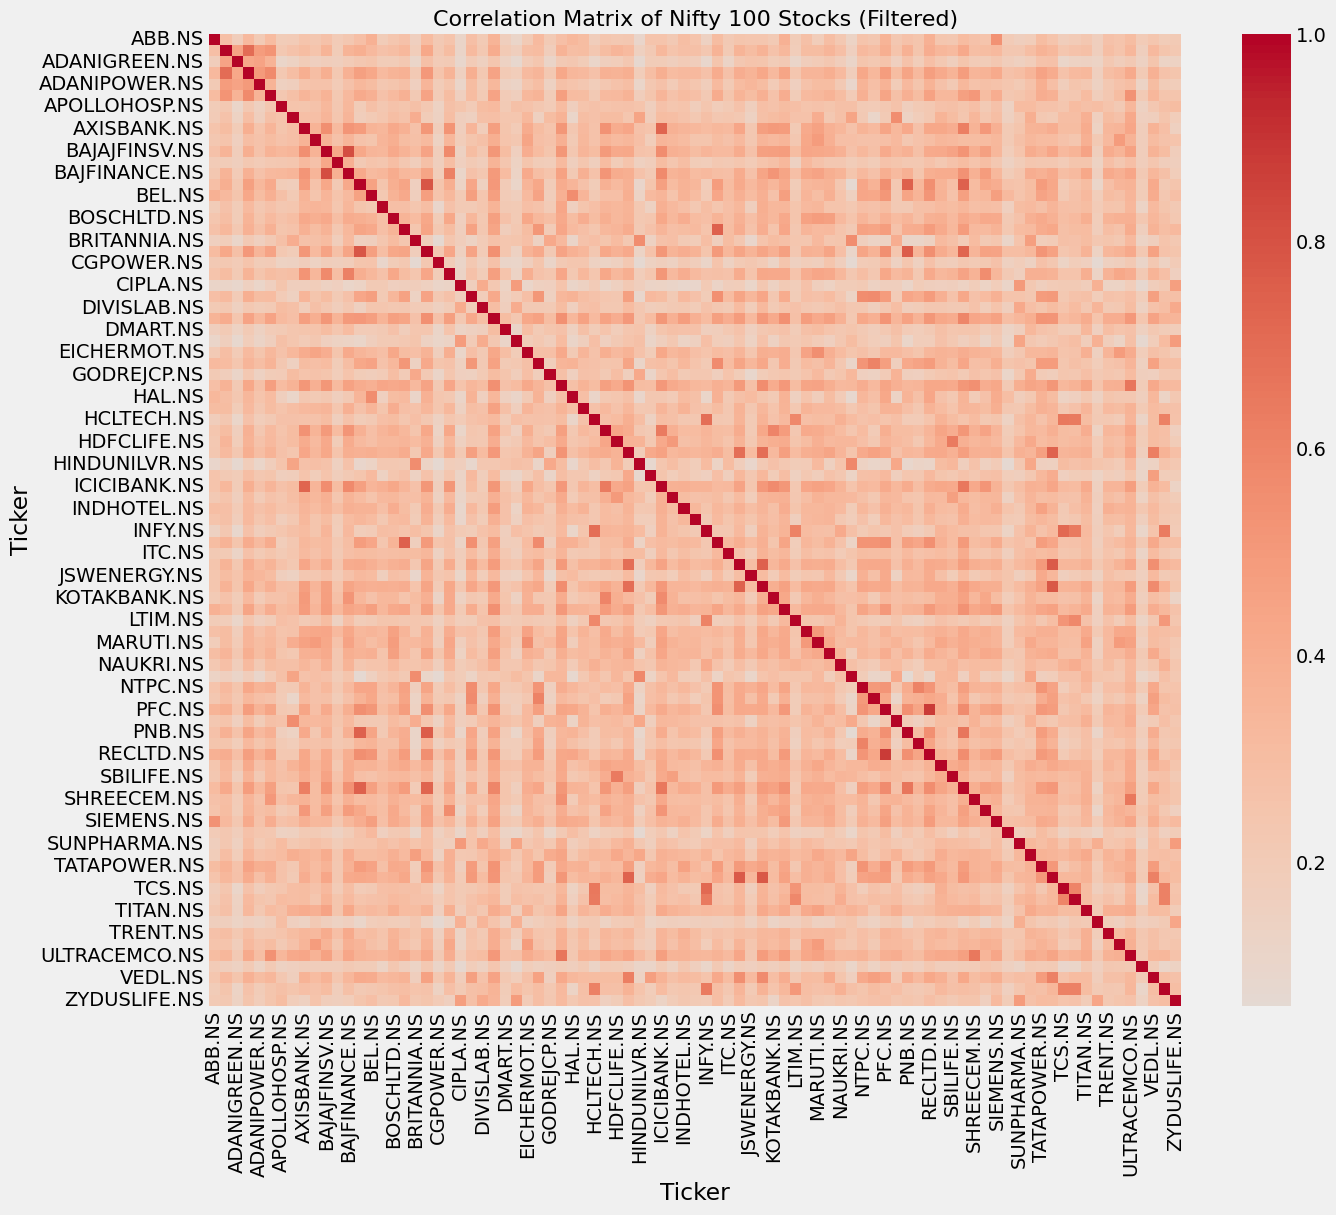

In [ ]:
# Step 2.2: Plotting the Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

# Calculate correlation of returns
correlation_matrix = returns.corr()

# Create a heatmap
# Red = High Correlation (Stocks move together)
# Blue = Low/Negative Correlation (Stocks move opposite/independently)
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True)

plt.title('Correlation Matrix of Nifty 100 Stocks (Filtered)', fontsize=16)
plt.show()

--- Top 20 Stocks by Expected Annual Return ---
Ticker
CGPOWER.NS       1.019662
HAL.NS           0.570849
BEL.NS           0.555514
SOLARINDS.NS     0.526476
ADANIPOWER.NS    0.509490
ADANIENT.NS      0.504517
VEDL.NS          0.450049
TVSMOTOR.NS      0.430712
TRENT.NS         0.425146
VBL.NS           0.423308
JSWENERGY.NS     0.403520
TATAPOWER.NS     0.396619
M&M.NS           0.396348
JINDALSTEL.NS    0.361124
ADANIGREEN.NS    0.350842
PFC.NS           0.342710
INDHOTEL.NS      0.332820
CHOLAFIN.NS      0.329104
HINDZINC.NS      0.325461
RECLTD.NS        0.325444
dtype: float64


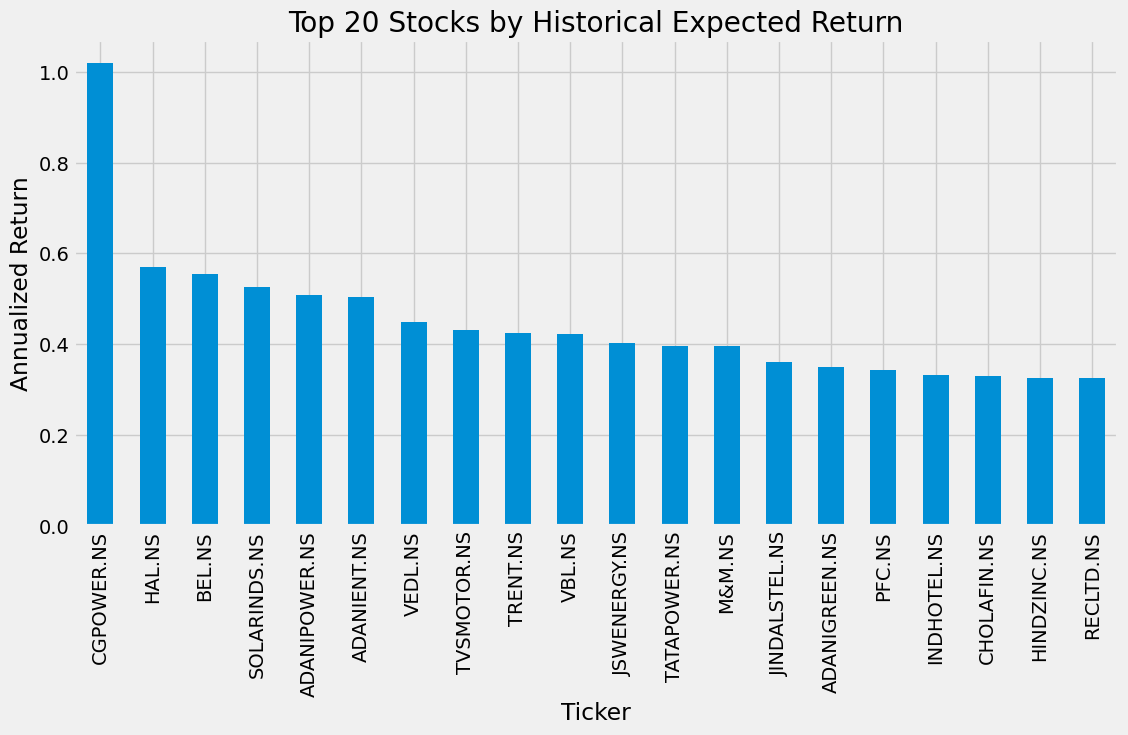

In [ ]:
from pypfopt import expected_returns, risk_models

# Calculate annualised expected returns
# This simply takes the average daily return and scales it to a year
mu = expected_returns.mean_historical_return(data)

print("--- Top 20 Stocks by Expected Annual Return ---")
print(mu.sort_values(ascending=False).head(20))

# Plotting the expected returns
plt.figure(figsize=(12, 6))
mu.sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Top 20 Stocks by Historical Expected Return")
plt.ylabel("Annualized Return")
plt.show()

In [ ]:
# 1. Sample Covariance
0S_sample = risk_models.sample_cov(data)

# 2. Ledoit-Wolf Shrinkage
S_shrinkage = risk_models.CovarianceShrinkage(data).ledoit_wolf()

print("Covariance Matrices calculated.")
print(f"Shape: {S_shrinkage.shape}")

# Let's verify they are actually different
difference_matrix = S_sample - S_shrinkage
max_diff = difference_matrix.abs().max().max()

print(f"\nMaximum difference between Sample and Shrinkage values: {max_diff:.6f}")
print("If this number is > 0, shrinkage has successfully adjusted the risk estimates.")

Covariance Matrices calculated.
Shape: (87, 87)

Maximum difference between Sample and Shrinkage values: 0.004594
If this number is > 0, shrinkage has successfully adjusted the risk estimates.


In [ ]:
from pypfopt import EfficientFrontier

# 1. Setup the Optimizer
# We pass in our Expected Returns (mu) and the Shrinkage Covariance (S_shrinkage)
# weight_bounds=(0, 0.10) ensures NO stock gets more than 10% allocation.
ef = EfficientFrontier(mu, S_shrinkage, weight_bounds=(0, 0.10))

# 2. Optimize for Maximum Sharpe Ratio
# This tells the solver: "Find the weights that maximize Return/Volatility"
raw_weights = ef.max_sharpe()

# 3. Clean the weights (removes tiny weights like 0.00001 to make it readable)
cleaned_weights = ef.clean_weights()

# 4. Display the Performance
print("--- Optimization Results (Max Sharpe) ---")
ef.portfolio_performance(verbose=True)

# 5. Show the top allocations
print("\n--- All Allocations ---")
pd.Series(cleaned_weights).sort_values(ascending=False).head(20)

--- Optimization Results (Max Sharpe) ---
Expected annual return: 45.4%
Annual volatility: 16.7%
Sharpe Ratio: 2.72

--- All Allocations ---


,0
CGPOWER.NS,0.10000
BHARTIARTL.NS,0.10000
SOLARINDS.NS,0.10000
TORNTPHARM.NS,0.10000
TVSMOTOR.NS,0.10000
VBL.NS,0.10000
HAL.NS,0.10000
CIPLA.NS,0.05490
HCLTECH.NS,0.05069
SUNPHARMA.NS,0.05028


In [ ]:
# 1. Initialize the Optimizer
ef_constrained = EfficientFrontier(mu, S_shrinkage, weight_bounds=(0, 0.10))

# --- THE FIX ---
# We must create a dictionary that explicitly sets the limit for EVERY sector found.
unique_sectors = set(cleaned_sector_map.values())

# Create limits: Lower = 0, Upper = 0.30 (30%)
sector_lower = {sector: 0 for sector in unique_sectors}
sector_upper = {sector: 0.30 for sector in unique_sectors}

# Now pass these dictionaries instead of raw numbers
ef_constrained.add_sector_constraints(cleaned_sector_map, sector_lower=sector_lower, sector_upper=sector_upper)
# ----------------

# 2. Optimize for Max Sharpe
weights_sector = ef_constrained.max_sharpe()
cleaned_weights_sector = ef_constrained.clean_weights()

# 3. Show Performance
print("--- Optimization Results (With Sector Constraints) ---")
ef_constrained.portfolio_performance(verbose=True)

# 4. Check the Sector Allocations
print("\n--- Sector Allocation Check ---")
import pandas as pd
weight_series = pd.Series(cleaned_weights_sector)
sector_weights = weight_series.groupby(cleaned_sector_map).sum().sort_values(ascending=False)
print(sector_weights.head())

--- Optimization Results (With Sector Constraints) ---
Expected annual return: 45.4%
Annual volatility: 16.7%
Sharpe Ratio: 2.72

--- Sector Allocation Check ---
Capital Goods                     0.24211
Healthcare                        0.23795
Automobile and Auto Components    0.11585
Fast Moving Consumer Goods        0.10858
Chemicals                         0.10000
dtype: float64


In [ ]:
from pypfopt import HRPOpt

# 1. Initialize the HRP Optimizer
# We use HRPOpt (Hierarchical Risk Parity Optimizer)
hrp = HRPOpt(returns)

# 2. Optimize
# HRP uses clustering to group stocks and allocates risk budget equally
weights_hrp = hrp.optimize()
cleaned_weights_hrp = hrp.clean_weights()

# 3. Show Performance
print("--- Optimization Results (Risk Parity / HRP) ---")
hrp.portfolio_performance(verbose=True)

# 4. Compare Allocations
print("\n--- Top 25 Allocations (Risk Parity) ---")
print(pd.Series(cleaned_weights_hrp).sort_values(ascending=False).head(25))

--- Optimization Results (Risk Parity / HRP) ---
Expected annual return: 25.3%
Annual volatility: 16.5%
Sharpe Ratio: 1.54

--- Top 25 Allocations (Risk Parity) ---
TCS.NS           0.02753
SUNPHARMA.NS     0.02580
BRITANNIA.NS     0.02344
ITC.NS           0.02246
ASIANPAINT.NS    0.02087
DMART.NS         0.01967
GODREJCP.NS      0.01911
BAJAJ-AUTO.NS    0.01883
SBILIFE.NS       0.01850
SOLARINDS.NS     0.01804
APOLLOHOSP.NS    0.01773
PIDILITIND.NS    0.01738
BHARTIARTL.NS    0.01705
VBL.NS           0.01700
NESTLEIND.NS     0.01696
ZYDUSLIFE.NS     0.01636
LT.NS            0.01631
TORNTPHARM.NS    0.01595
RELIANCE.NS      0.01579
INFY.NS          0.01555
HCLTECH.NS       0.01554
HINDUNILVR.NS    0.01522
BOSCHLTD.NS      0.01520
DRREDDY.NS       0.01517
INDIGO.NS        0.01464
dtype: float64


1. Re-calculating Constrained MVO weights...
2. Re-calculating Risk Parity weights...
3. Running Backtest...


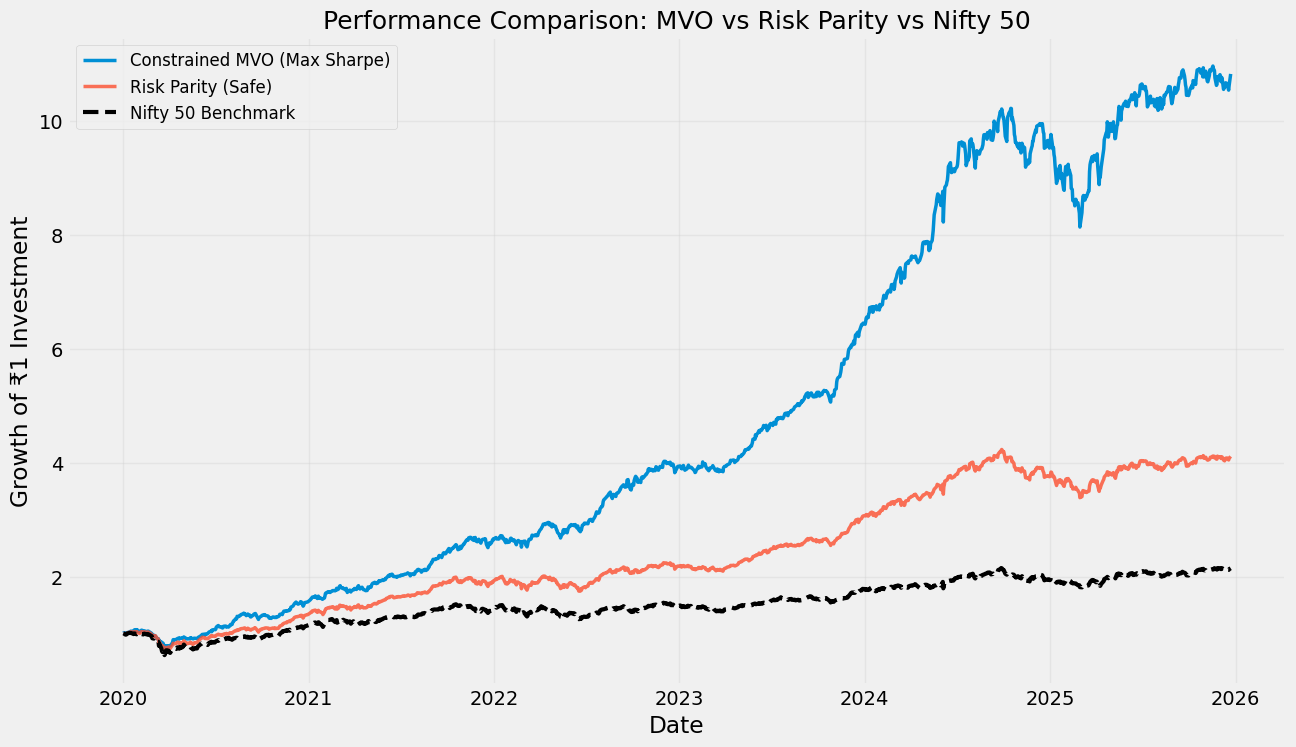


--- Final Total Return (%) ---
Constrained MVO       981.738669
Risk Parity (HRP)     310.942414
Nifty 50 Benchmark    114.836039
Name: 2025-12-22 00:00:00, dtype: float64


In [ ]:
# --- MASTER CELL: RE-CALCULATE AND BACKTEST ---

import pandas as pd
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, HRPOpt

# ==========================================
# PART A: Re-Calculate Constrained MVO (Phase 5)
# ==========================================
print("1. Re-calculating Constrained MVO weights...")
ef_constrained = EfficientFrontier(mu, S_shrinkage, weight_bounds=(0, 0.10))

# Create the sector limits again
unique_sectors = set(cleaned_sector_map.values())
sector_lower = {sector: 0 for sector in unique_sectors}
sector_upper = {sector: 0.30 for sector in unique_sectors}

# Add constraints
ef_constrained.add_sector_constraints(cleaned_sector_map, sector_lower=sector_lower, sector_upper=sector_upper)

# Optimize
ef_constrained.max_sharpe()
cleaned_weights_sector = ef_constrained.clean_weights() # <--- Variable defined here!

# ==========================================
# PART B: Re-Calculate Risk Parity (Phase 6)
# ==========================================
print("2. Re-calculating Risk Parity weights...")
hrp = HRPOpt(returns)
hrp.optimize()
cleaned_weights_hrp = hrp.clean_weights()

# ==========================================
# PART C: The Backtest (Visualization)
# ==========================================
print("3. Running Backtest...")

# 1. Get the weights
w_mvo = cleaned_weights_sector
w_hrp = cleaned_weights_hrp

# 2. Calculate Portfolio Returns
port_ret_mvo = (returns * pd.Series(w_mvo)).sum(axis=1)
port_ret_hrp = (returns * pd.Series(w_hrp)).sum(axis=1)

# 3. Process Benchmark (Squeeze to fix the shape error)
bench_ret_series = benchmark_returns.squeeze()

# 4. Create Comparison DataFrame
backtest_df = pd.DataFrame({
    'Constrained MVO': port_ret_mvo,
    'Risk Parity (HRP)': port_ret_hrp,
    'Nifty 50 Benchmark': bench_ret_series
}).dropna()

# 5. Calculate Cumulative Returns
cumulative_returns = (1 + backtest_df).cumprod()

# 6. Plotting
plt.figure(figsize=(14, 8))
plt.plot(cumulative_returns['Constrained MVO'], label='Constrained MVO (Max Sharpe)', linewidth=2.5)
plt.plot(cumulative_returns['Risk Parity (HRP)'], label='Risk Parity (Safe)', linewidth=2.5, alpha=0.8)
plt.plot(cumulative_returns['Nifty 50 Benchmark'], label='Nifty 50 Benchmark', color='black', linewidth=3, linestyle='--')

plt.title('Performance Comparison: MVO vs Risk Parity vs Nifty 50', fontsize=18)
plt.ylabel('Growth of ₹1 Investment')
plt.xlabel('Date')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 7. Final Output
print("\n--- Final Total Return (%) ---")
print((cumulative_returns.iloc[-1] - 1) * 100)

In [ ]:
# --- STEP 1: CALCULATE METRICS (CAGR, DRAWDOWN, SHARPE) ---
import numpy as np

# Helper function to calculate Max Drawdown
def calculate_drawdown(return_series):
    comp_ret = (1 + return_series).cumprod()
    peak = comp_ret.cummax()
    drawdown = (comp_ret - peak) / peak
    return drawdown.min() * 100  # Return as percentage

# Helper function for CAGR
def calculate_cagr(return_series):
    n_years = len(return_series) / 252 # Assuming 252 trading days
    total_ret = (1 + return_series).cumprod().iloc[-1]
    cagr = (total_ret ** (1/n_years)) - 1
    return cagr * 100

# Helper function for Sharpe (assuming Risk Free Rate = 7%)
def calculate_sharpe(return_series, rf=0.07):
    mean_ret = return_series.mean() * 252
    volatility = return_series.std() * np.sqrt(252)
    sharpe = (mean_ret - rf) / volatility
    return sharpe

# Create a Metrics Table
metrics_data = []

# Loop through our 3 portfolios in the backtest_df
for col in backtest_df.columns:
    series = backtest_df[col]

    cagr = calculate_cagr(series)
    mdd = calculate_drawdown(series)
    sharpe = calculate_sharpe(series)
    vol = series.std() * np.sqrt(252) * 100

    metrics_data.append([col, f"{cagr:.2f}%", f"{vol:.2f}%", f"{sharpe:.2f}", f"{mdd:.2f}%"])

# Convert to DataFrame for nice printing
metrics_df = pd.DataFrame(metrics_data, columns=["Strategy", "CAGR (Growth)", "Volatility", "Sharpe Ratio", "Max Drawdown"])
print("--- FINAL PERFORMANCE REPORT ---")
print(metrics_df)

--- FINAL PERFORMANCE REPORT ---
             Strategy CAGR (Growth) Volatility Sharpe Ratio Max Drawdown
0     Constrained MVO        50.04%     16.86%         2.08      -28.53%
1   Risk Parity (HRP)        27.23%     16.45%         1.12      -33.16%
2  Nifty 50 Benchmark        13.92%     18.13%         0.42      -38.44%
